<a href="https://colab.research.google.com/github/dipenthakercalypso/dl-genai-project/blob/practice/DL_GenAI_Project_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Implement the SRCNN model for Super-Resolution using a standard dataset like Set5 or Set14.

## Set up the environment

### Subtask:
Install necessary libraries like TensorFlow or PyTorch, and download the chosen dataset (Set5 or Set14).


**Reasoning**:
Install TensorFlow using pip and download and extract the Set5 dataset.



Extracting /content/sample_data/Set5-Set14.zip to /kaggle/working/Set5-Set14...
Extraction complete.
Found images in /kaggle/working/Set5-Set14/Set5/Set5
Prepared 5 image pairs from Set5 with size (256, 256).
High-resolution images count: 5
Low-resolution images count: 5
Interpolated images count: 5


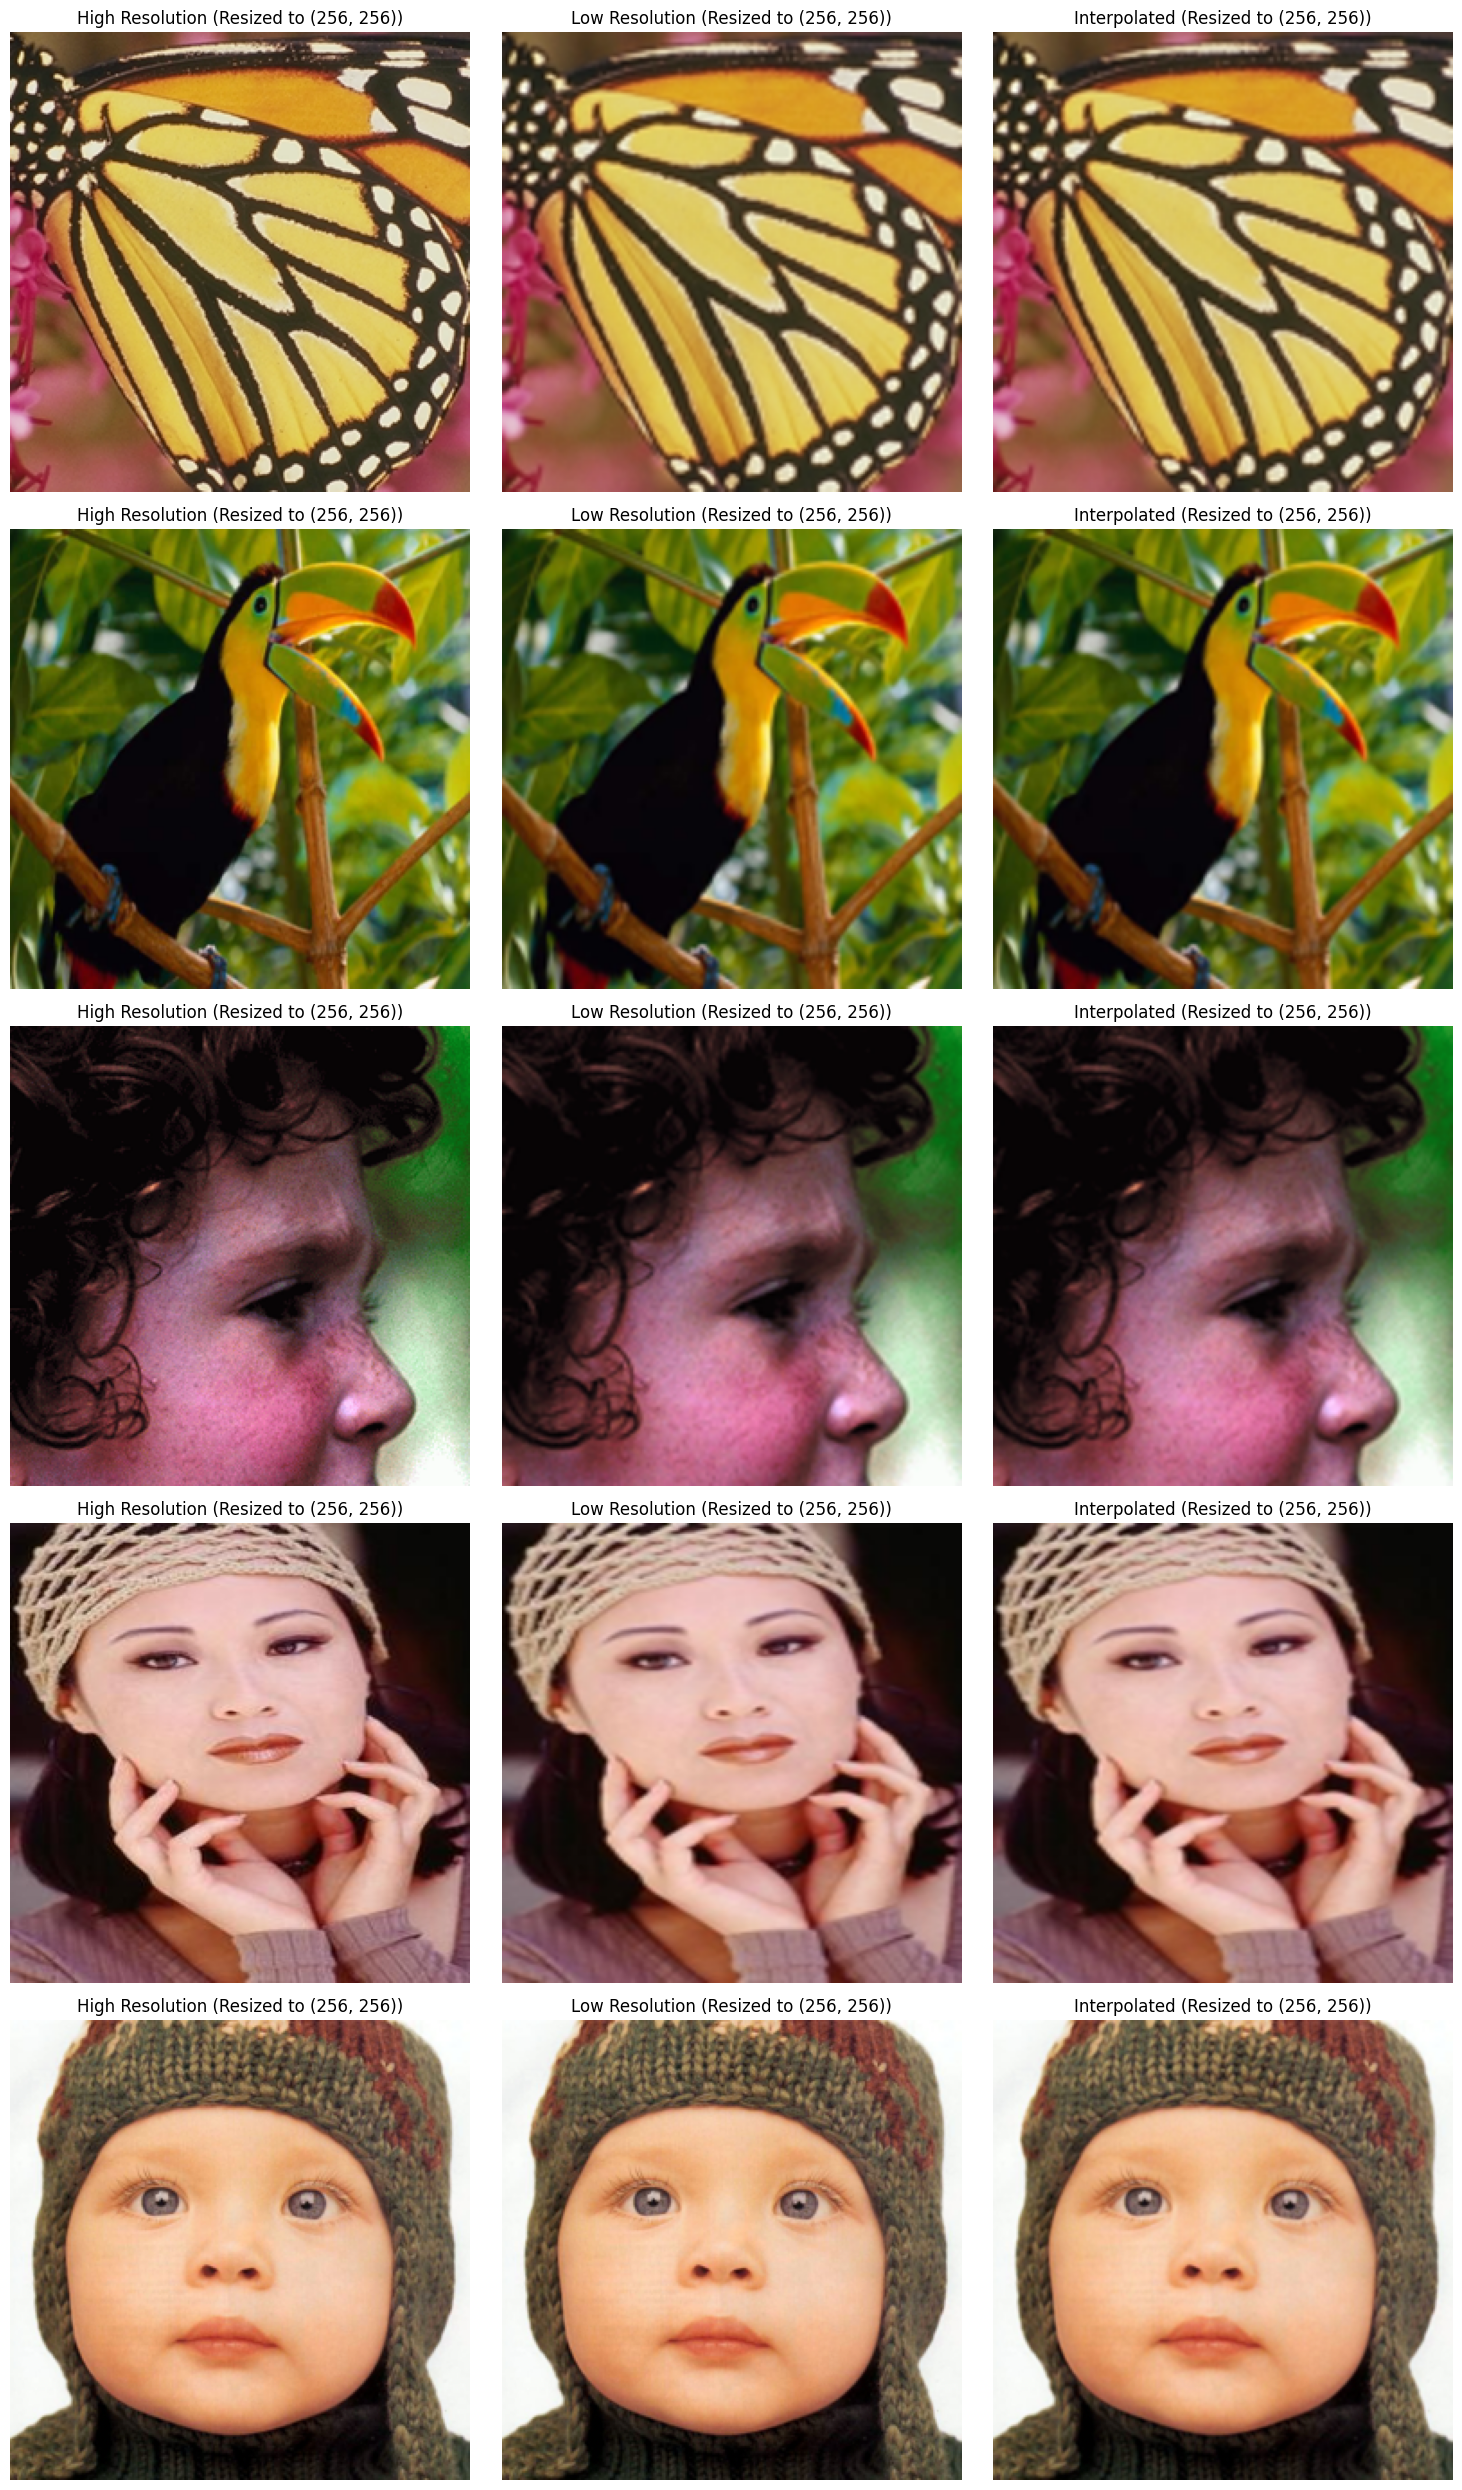

Prepared 5 image pairs with consistent shape (256, 256, 3).


In [20]:
import os
import numpy as np
from PIL import Image
import zipfile
import random
import matplotlib.pyplot as plt

# Define the path to the uploaded Set5-Set14 dataset zip file
dataset_zip_path = "/content/sample_data/Set5-Set14.zip"
extract_path = "/kaggle/working/Set5-Set14"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the dataset
if os.path.exists(dataset_zip_path):
    print(f"Extracting {dataset_zip_path} to {extract_path}...")
    try:
        with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Extraction complete.")
    except zipfile.BadZipFile:
        print(f"Error: {dataset_zip_path} is not a valid zip file.")
    except Exception as e:
        print(f"Error during extraction: {e}")
else:
    print(f"Error: Dataset zip file not found at {dataset_zip_path}")


# Get a list of high-resolution image files from the extracted Set5 folders
# Updated path based on the directory structure observed
set5_extracted_path_option1 = os.path.join(extract_path, "Set5", "Set5")
set5_extracted_path_option2 = os.path.join(extract_path, "set5", "Set5")

hr_image_files = []

if os.path.exists(set5_extracted_path_option1):
    hr_image_files.extend([os.path.join(set5_extracted_path_option1, f) for f in os.listdir(set5_extracted_path_option1) if f.endswith(('.png', '.jpg', '.bmp'))])
    print(f"Found images in {set5_extracted_path_option1}")
elif os.path.exists(set5_extracted_path_option2):
     hr_image_files.extend([os.path.join(set5_extracted_path_option2, f) for f in os.listdir(set5_extracted_path_option2) if f.endswith(('.png', '.jpg', '.bmp'))])
     print(f"Found images in {set5_extracted_path_option2}")
else:
    print(f"Error: Set5 directory not found within the extracted data at either {set5_extracted_path_option1} or {set5_extracted_path_option2}")


# Prepare lists to store HR, LR, and interpolated images
hr_images = []
lr_images = []
interpolated_images = []

scale_factor = 2 # Define the scaling factor (e.g., 2x, 3x, 4x)
target_size = (256, 256) # Define a fixed target size for training

for hr_path in hr_image_files:
    # Load the high-resolution image
    hr_img = Image.open(hr_path).convert('RGB')

    # Create low-resolution image
    lr_img = hr_img.resize((hr_img.width // scale_factor, hr_img.height // scale_factor), Image.BICUBIC)
    # Resize the low-resolution image to target_size for consistent plotting
    lr_img_resized = lr_img.resize(target_size, Image.BICUBIC)
    lr_images.append(np.array(lr_img_resized))

    # Create interpolated image (input for SRCNN) and resize to target_size
    interpolated_img = lr_img.resize((hr_img.width, hr_img.height), Image.BICUBIC)
    interpolated_img_resized = interpolated_img.resize(target_size, Image.BICUBIC)
    interpolated_images.append(np.array(interpolated_img_resized))

    # Resize the high-resolution image to target_size
    hr_img_resized = hr_img.resize(target_size, Image.BICUBIC)
    hr_images.append(np.array(hr_img_resized))


print(f"Prepared {len(hr_images)} image pairs from Set5 with size {target_size}.")
print(f"High-resolution images count: {len(hr_images)}")
print(f"Low-resolution images count: {len(lr_images)}") # Note: LR images are not resized to target_size
print(f"Interpolated images count: {len(interpolated_images)}")


# --- Add plotting of random images ---
if len(hr_images) > 0:
    num_images_to_plot = min(10, len(hr_images))
    random_indices = random.sample(range(len(hr_images)), num_images_to_plot)

    plt.figure(figsize=(15, num_images_to_plot * 5))

    for i, idx in enumerate(random_indices):
        # Plot High-Resolution Image (resized for training)
        plt.subplot(num_images_to_plot, 3, i * 3 + 1)
        plt.imshow(hr_images[idx])
        plt.title(f"High Resolution (Resized to {target_size})")
        plt.axis('off')

        # Plot Low-Resolution Image (resized for plotting)
        plt.subplot(num_images_to_plot, 3, i * 3 + 2)
        plt.imshow(lr_images[idx]) # Plotting original LR size
        plt.title(f"Low Resolution (Resized to {target_size})")
        plt.axis('off')

        # Plot Interpolated Image (resized for training)
        plt.subplot(num_images_to_plot, 3, i * 3 + 3)
        plt.imshow(interpolated_images[idx])
        plt.title(f"Interpolated (Resized to {target_size})")
        plt.axis('off')


    plt.tight_layout()
    plt.show()
else:
    print("No images were prepared, cannot plot.")

# --- End plotting code ---

# Now hr_images and interpolated_images are lists of NumPy arrays with consistent shape (256, 256, 3)
# We can convert them to NumPy arrays for easier handling in training
hr_images = np.array(hr_images)
interpolated_images = np.array(interpolated_images)

print(f"Prepared {len(hr_images)} image pairs with consistent shape {hr_images.shape[1:]}.")

**Reasoning**: Inspect the contents of the extracted directory to find the correct path to the Set5 images.

In [11]:
import os

extracted_path = "/kaggle/working/Set5-Set14"

if os.path.exists(extracted_path):
    print(f"Contents of {extracted_path}:")
    # List all files and directories in the extracted path
    for root, dirs, files in os.walk(extracted_path):
        level = root.replace(extracted_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')
else:
    print(f"Error: Extraction path not found at {extracted_path}")

Contents of /kaggle/working/Set5-Set14:
Set5-Set14/
    Set5/
        Set5/
            head.png
            butterfly.png
            woman.png
            bird.png
            baby.png
    Set14/
        Set14/
            zebra.png
            man.png
            comic.png
            lenna.png
            face.png
            coastguard.png
            pepper.png
            flowers.png
            baboon.png
            bridge.png
            ppt3.png
            barbara.png
            monarch.png
            foreman.png
    set5/
        Set5/
            head.png
            butterfly.png
            woman.png
            bird.png
            baby.png
    set14/
        Set14/
            zebra.png
            man.png
            comic.png
            lenna.png
            face.png
            coastguard.png
            pepper.png
            flowers.png
            baboon.png
            bridge.png
            ppt3.png
            barbara.png
            monarch.png
          

**Reasoning**: Define the SRCNN model architecture with three convolutional layers.

In [16]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input
from tensorflow.keras.models import Model

def srcnn_model():
    # Input layer: takes the interpolated low-resolution image
    # The shape is None for height and width to allow for variable image sizes
    input_img = Input(shape=(None, None, 3))

    # Layer 1: Extracts patches from the input image
    # 64 filters of size 9x9
    x = Conv2D(filters=64, kernel_size=(9, 9), kernel_initializer='he_normal', activation='relu', padding='same')(input_img) # Changed padding to 'same'

    # Layer 2: Non-linear mapping of the patches
    # 32 filters of size 1x1
    x = Conv2D(filters=32, kernel_size=(1, 1), kernel_initializer='he_normal', activation='relu', padding='same')(x) # Changed padding to 'same'

    # Layer 3: Reconstruction of the high-resolution image
    # 3 filters (for RGB channels) of size 5x5
    output_img = Conv2D(filters=3, kernel_size=(5, 5), kernel_initializer='he_normal', padding='same')(x) # Changed padding to 'same'

    # Create the model
    model = Model(inputs=input_img, outputs=output_img)

    return model

# Create the SRCNN model
srcnn = srcnn_model()

# Print the model summary
srcnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, None, None, 64) │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, None, None, 32) │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, None, None, 3)  │         2,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,099 (78.51 KB)

 Trainable params: 20,099 (78.51 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**: Compile the SRCNN model by specifying the optimizer, loss function, and evaluation metrics.

In [23]:
import tensorflow as tf

# Define PSNR as a metric
def psnr(y_true, y_pred):
    max_pixel = 255.0  # Assuming image pixel values are between 0 and 255
    return tf.image.psnr(y_true, y_pred, max_val=max_pixel)

# Compile the model
srcnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mse',  # Mean Squared Error
              metrics=[psnr])

print("Model compiled successfully.")

Model compiled successfully.


**Reasoning**: Train the SRCNN model using the prepared dataset.

In [24]:
# Train the model
# Since the images have different sizes, we'll train one image at a time in this example.
# For a larger dataset and more efficient training, you would typically use a data generator
# or pad/crop images to a consistent size and use batch training.

epochs = 10  # Define the number of training epochs

print(f"Starting training for {epochs} epochs...")

# Iterate over epochs
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    # Iterate over each image in the dataset
    for i in range(len(interpolated_images)):
        # Get the interpolated input and the corresponding high-resolution target
        input_img = interpolated_images[i]
        target_img = hr_images[i]

        # Ensure input and target have the same dimensions by cropping to the minimum size
        min_height = min(input_img.shape[0], target_img.shape[0])
        min_width = min(input_img.shape[1], target_img.shape[1])

        input_img_cropped = input_img[:min_height, :min_width, :]
        target_img_cropped = target_img[:min_height, :min_width, :]

        # Add batch dimension
        input_img_cropped = np.expand_dims(input_img_cropped, axis=0)
        target_img_cropped = np.expand_dims(target_img_cropped, axis=0)


        # Train the model on the single image
        history = srcnn.train_on_batch(input_img_cropped, target_img_cropped)

        # Print loss and metrics for the current image (optional)
        print(f"  Image {i+1}: Loss = {history[0]:.4f}, PSNR = {history[1]:.4f}")

    # You can add evaluation on a validation set here if you have one
    # For simplicity, we'll just print epoch end message
    print(f"Epoch {epoch + 1} finished.")

print("Training complete.")

Starting training for 10 epochs...
Epoch 1/10
  Image 1: Loss = 34771.2734, PSNR = -42.4144
  Image 2: Loss = 34152.8516, PSNR = -41.4063
  Image 3: Loss = 26810.2520, PSNR = -40.5836
  Image 4: Loss = 20933.0801, PSNR = -39.4739
  Image 5: Loss = 17232.5273, PSNR = -40.5418
Epoch 1 finished.
Epoch 2/10
  Image 1: Loss = 14639.5117, PSNR = -40.7720
  Image 2: Loss = 13267.7051, PSNR = -41.3930
  Image 3: Loss = 12205.3262, PSNR = -41.9205
  Image 4: Loss = 11050.5928, PSNR = -41.7342
  Image 5: Loss = 10272.5947, PSNR = -42.0511
Epoch 2 finished.
Epoch 3/10
  Image 1: Loss = 9412.2334, PSNR = -41.8936
  Image 2: Loss = 8896.7295, PSNR = -41.9494
  Image 3: Loss = 8313.8125, PSNR = -42.0086
  Image 4: Loss = 7799.4155, PSNR = -41.7480
  Image 5: Loss = 7374.5781, PSNR = -41.8227
Epoch 3 finished.
Epoch 4/10
  Image 1: Loss = 6952.2085, PSNR = -41.6735
  Image 2: Loss = 6676.3735, PSNR = -41.7226
  Image 3: Loss = 6395.2231, PSNR = -41.8246
  Image 4: Loss = 6101.7529, PSNR = -41.6927
  

**Reasoning**: Evaluate the trained SRCNN model using the prepared dataset and calculate PSNR.

In [25]:
# Evaluate the model
print("Evaluating the model...")

# Predict high-resolution images using the trained model
predicted_images = srcnn.predict(interpolated_images)

# Calculate PSNR for each image
psnr_values = []
for i in range(len(hr_images)):
    # Ensure the predicted and target images have the same shape for PSNR calculation
    # The model output shape should match the input shape (interpolated_images shape)
    # and since hr_images were resized to the same shape, they should match.
    # Convert to float32 for PSNR calculation
    hr_img_float = tf.cast(hr_images[i], tf.float32)
    predicted_img_float = tf.cast(predicted_images[i], tf.float32)

    # PSNR requires values in the range [0, max_val]
    # Assuming pixel values are in [0, 255]
    current_psnr = tf.image.psnr(hr_img_float, predicted_img_float, max_val=255.0)
    psnr_values.append(current_psnr.numpy())


# Calculate and print the average PSNR
average_psnr = np.mean(psnr_values)
print(f"Average PSNR on the dataset: {average_psnr:.4f} dB")

print("Evaluation complete.")

Evaluating the model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step
Average PSNR on the dataset: 22.2484 dB
Evaluation complete.


**Reasoning**: Visualize the original high-resolution images, interpolated inputs, and the SRCNN model's predictions for a few examples.

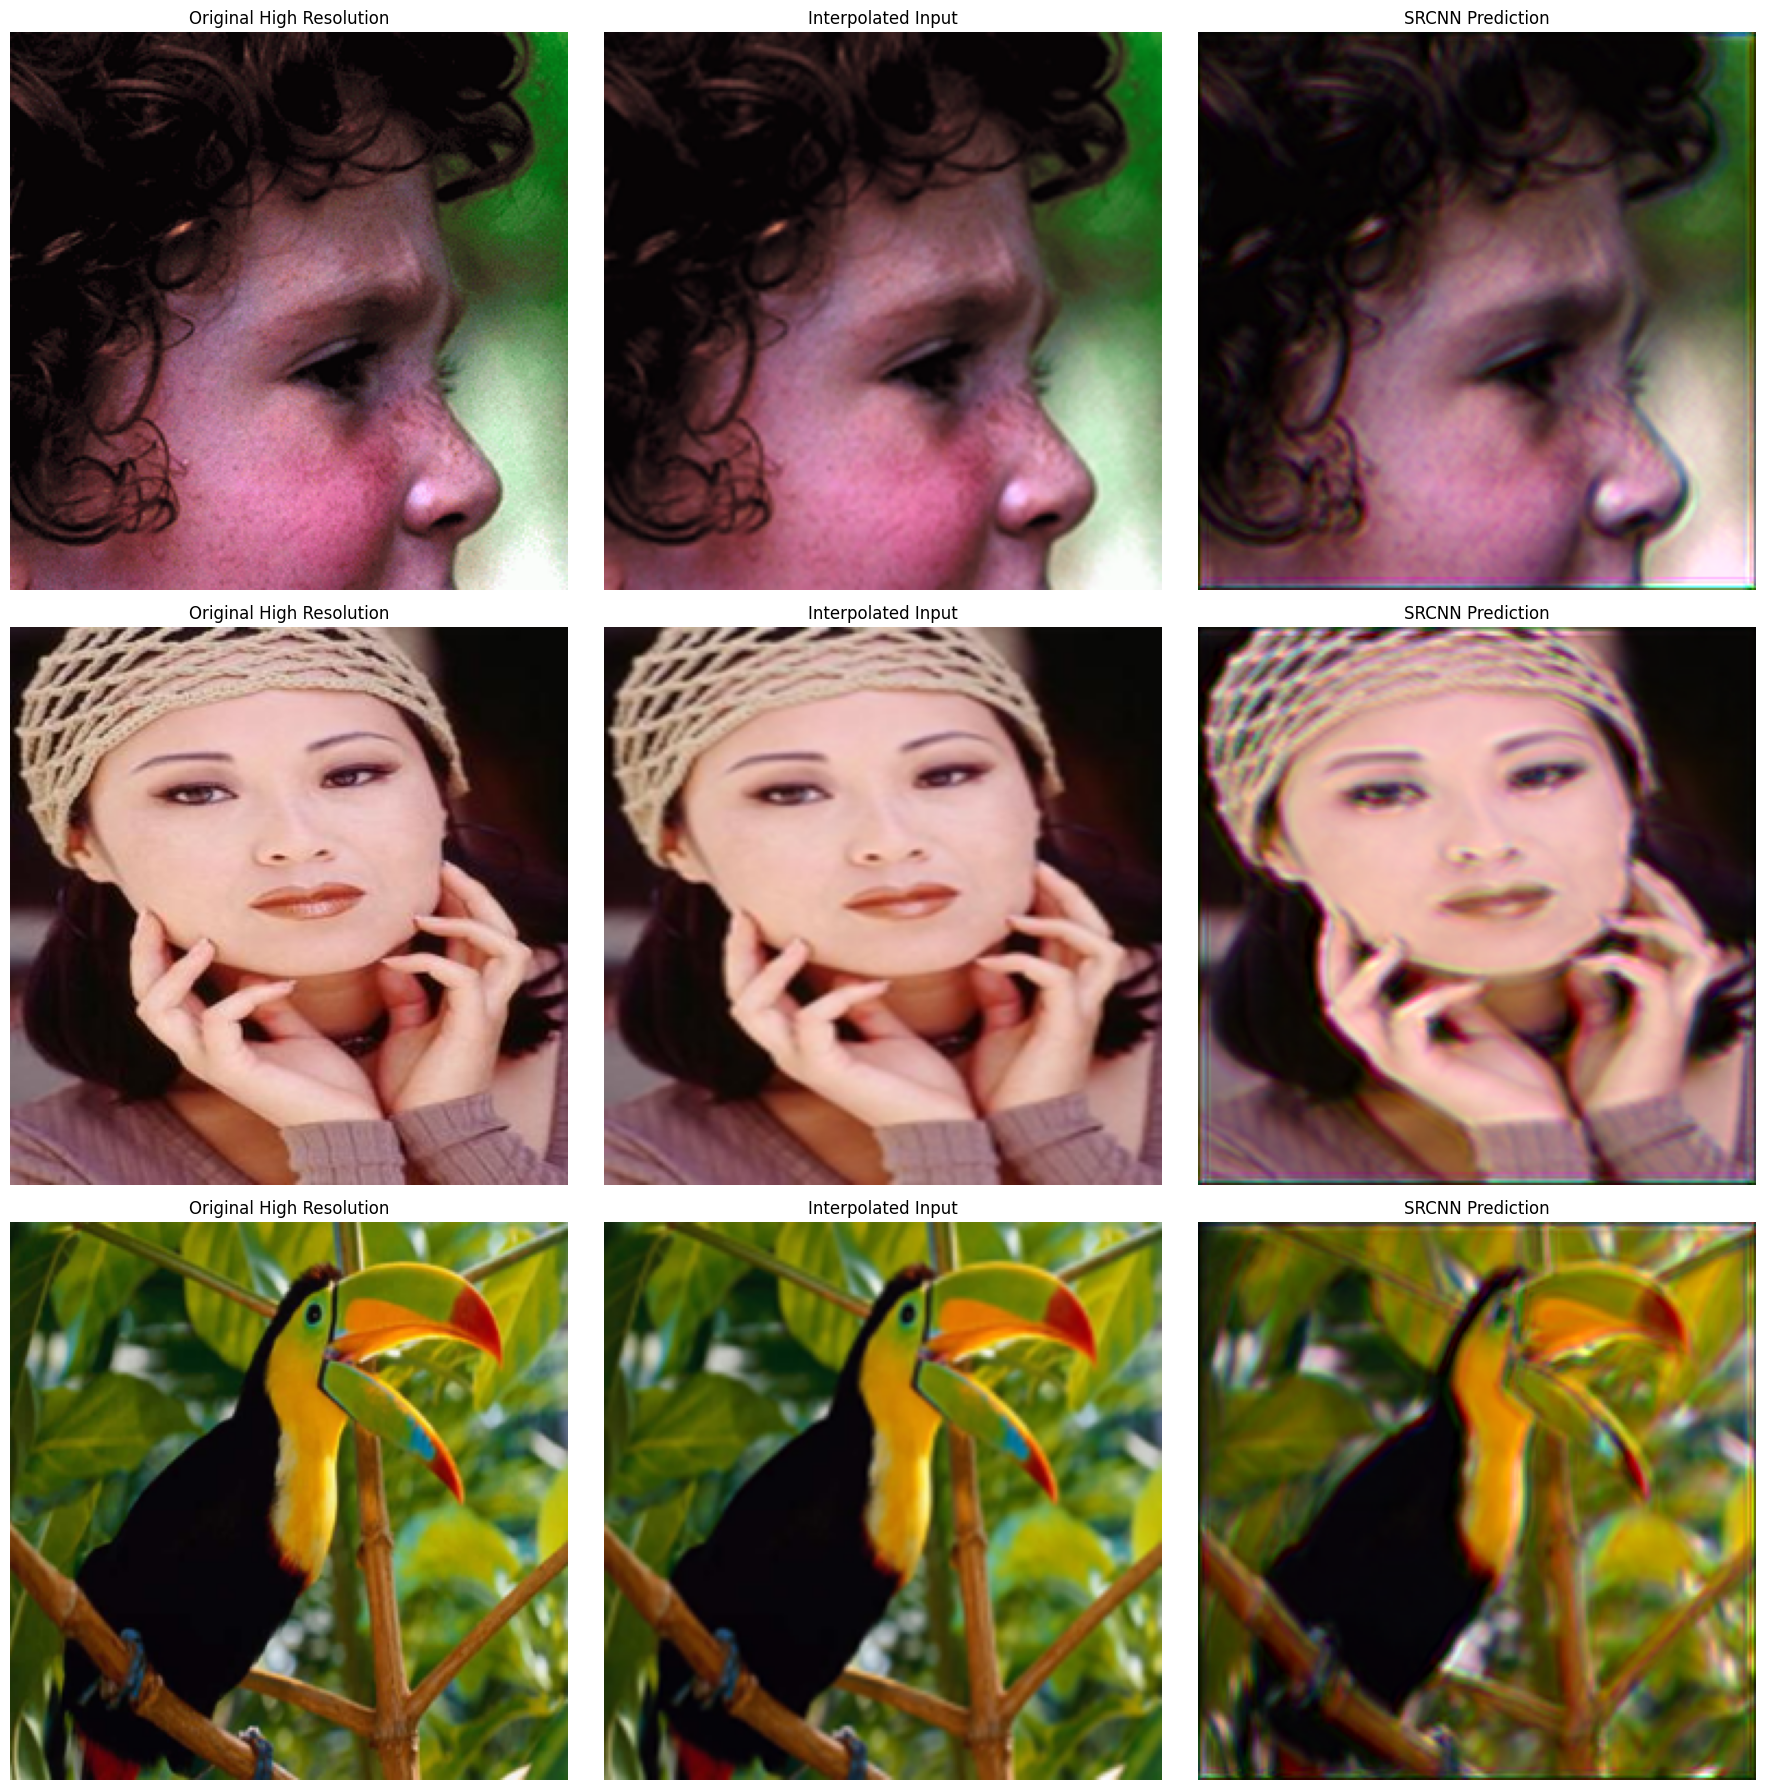

In [26]:
import matplotlib.pyplot as plt
import random

# Select a few random indices to visualize
num_examples_to_visualize = 3
random_indices = random.sample(range(len(hr_images)), num_examples_to_visualize)

plt.figure(figsize=(18, num_examples_to_visualize * 6))

for i, idx in enumerate(random_indices):
    # Original High-Resolution Image
    plt.subplot(num_examples_to_visualize, 3, i * 3 + 1)
    plt.imshow(hr_images[idx])
    plt.title("Original High Resolution")
    plt.axis('off')

    # Interpolated Input Image
    plt.subplot(num_examples_to_visualize, 3, i * 3 + 2)
    plt.imshow(interpolated_images[idx])
    plt.title("Interpolated Input")
    plt.axis('off')

    # SRCNN Predicted High-Resolution Image
    plt.subplot(num_examples_to_visualize, 3, i * 3 + 3)
    # Clip values to be in valid range [0, 255] and convert to uint8 for displaying
    predicted_img_clipped = np.clip(predicted_images[idx], 0, 255).astype(np.uint8)
    plt.imshow(predicted_img_clipped)
    plt.title("SRCNN Prediction")
    plt.axis('off')

plt.tight_layout()
plt.show()